In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sqlite3 
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('customer_churn_.db')

sql_query = '''

select name 
from sqlite_master
where type = 'table'

'''

tables = pd.read_sql(sql_query , conn)

for table_name in tables['name']:
    df = pd.read_sql(f"select * from {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"created dataframe df_{table_name}")

conn.close()


created dataframe df_db_customer
created dataframe df_db_subscription
created dataframe df_db_support


In [3]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [4]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [5]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 2.5+ KB


In [6]:
df_db_customer = df_db_customer.drop('interests',axis=1)

In [7]:
df_db_customer = df_db_customer.rename(columns={'name':'customer_name'})

In [8]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [9]:
country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()


df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(country_mapping))

In [10]:
df_db_customer.iloc[[8]]

,customerid,customer_name,country,state,gender,dob,pincode
8,0015-UOCOJ,maya,Nepal,Kathmandu,Women,1985-07-07,None


In [11]:
df_db_customer['gender'].unique()

<ArrowStringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [12]:

df_db_customer['gender'] = df_db_customer['gender'].replace('Men','Male')
df_db_customer['gender'] = df_db_customer['gender'].replace('Women','Female')

In [13]:
df_db_customer.iloc[[8]]

,customerid,customer_name,country,state,gender,dob,pincode
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07,None


In [14]:
df_db_customer.loc[8]

customerid                0015-UOCOJ
customer_name                   maya
country                        Nepal
state                      Kathmandu
gender                        Female
dob              1985-07-07 00:00:00
pincode                         None
Name: 8, dtype: object

In [15]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 3.1 KB


In [16]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [17]:
df_db_subscription.duplicated().sum()

np.int64(0)

In [18]:
df_db_subscription['subscription_start_date'] = pd.to_datetime(df_db_subscription['subscription_start_date'])


In [19]:
df_db_subscription['renewal_date'] = pd.to_datetime(df_db_subscription['renewal_date'])


In [20]:
df_db_subscription['cancellation_date'] = pd.to_datetime(df_db_subscription['cancellation_date'])

In [21]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 895.0+ bytes


In [22]:
df_db_support.head(5)

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [23]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [24]:
df_db_support = df_db_support.drop('col_1',axis=1)

In [25]:
df_db_customer=df_db_customer.drop('pincode',axis=1)

In [26]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [27]:
df_db_support[df_db_support['customerid'].duplicated()]

,customerid,complaint_date,escalations,csat_score,comment
1,0003-MKNFE,2024-08-28,Y,10,demaned refund
8,0022-TCJCI,2024-09-14,N,90,received refund


In [28]:
df_db_support['count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [29]:
df_db_support=df_db_support.sort_values('complaint_date')

In [30]:
df_db_support=df_db_support.drop_duplicates('customerid',keep = 'last')

In [31]:
df = (df_db_subscription.merge(df_db_customer ,on = 'customerid' , how = 'left')
                        .merge(df_db_support ,on = 'customerid' , how = 'left'))

In [32]:
df.shape

(21, 22)

In [33]:
df_db_support=df_db_support.drop('comment' , axis =1)

In [34]:
df_db_support

,customerid,complaint_date,escalations,csat_score,count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [35]:
df.shape

(21, 22)

In [36]:
df.to_csv('exported_churn_data.csv')

In [37]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment', 'count'],
      dtype='str')

In [38]:
#1 churn rate

In [39]:
churn_rate = df['churn_flag'].mean()*100

In [40]:
print('churn rate is',round(churn_rate,2),'%')

churn rate is 28.57 %


In [41]:
#2 retention rate

In [42]:
retention_rate = 100-churn_rate

In [43]:
print('Retention rate is ',round(retention_rate,2),'%')

Retention rate is  71.43 %


In [44]:
#3 churn by plan type

In [45]:
# churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct')

In [46]:
churn_by_plan = (
    df.groupby('plan_type')
      .agg(
          customer_count=('customerid', 'count'),
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          sum_revenue = ('monthly_charges','sum')
      )
      .reset_index()
)

In [47]:
churn_by_plan

,plan_type,customer_count,churn_rate_pct,sum_revenue
0,Basic,5,60.00,52.95
1,Premium,7,14.29,218.93
2,Standard,9,22.22,123.91


In [48]:
#4 churn_by_state

In [49]:
churn_by_state = (
    df.groupby('state')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          customer_count=('customerid', 'count'),
          sum_revenue = ('monthly_charges','sum')
      )
      .reset_index()
)

In [50]:
churn_by_state

,state,churn_rate_pct,customer_count,sum_revenue
0,Delhi,25.00,4,52.96
1,Karnataka,100.00,2,20.98
2,Kathmandu,0.00,2,20.98
3,Maharashtra,0.00,3,50.97
4,Meghalaya,66.67,3,42.97
5,Nagaland,0.00,1,22.99
6,Rajasthan,0.00,2,36.98
7,Telangana,50.00,2,30.98
8,Uttar Pradesh,0.00,2,115.98


In [51]:
#5 churn_by_subscription

In [52]:
churn_by_subscription = (
    df.groupby('subscription_type')
      .agg(
          churn_rate_pct = ('churn_flag', lambda x: round(x.mean() * 100, 2)),
          customer_count = ('customerid', 'count'),
          sum_revenue = ('monthly_charges','sum')
      )
      .reset_index()
)

In [53]:
churn_by_subscription

,subscription_type,churn_rate_pct,customer_count,sum_revenue
0,Organic,0.00,9,145.91
1,Paid,16.67,6,174.94
2,Refferal,83.33,6,74.94


In [54]:
avg_revenue_per_user = df.groupby("customerid").agg(arpu = ('monthly_charges','sum')).reset_index()

In [55]:
# avg_rev_per_user
arpu = df['monthly_charges'].mean()
print(round(arpu,2))

18.85


In [56]:
avg_revenue_per_user.head(2)

,customerid,arpu
0,0002-ORFBO,13.99
1,0003-MKNFE,12.99


In [57]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment', 'count'],
      dtype='str')

In [58]:
#6 tenure calculation

In [59]:
today = pd.Timestamp.today()

df['tenure'] = np.where(

    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
    
)

df['tenure']=df['tenure'].astype(int)


In [60]:
avg_tenure = round(df['tenure'].mean(),2).astype(int)
print(avg_tenure)

1490


In [61]:
#7 customer age

In [62]:
today = pd.Timestamp.today()
df['age'] = round(((today - df['dob']).dt.days/365)).astype(int)

In [63]:
#8 revenue at risk 

In [64]:
risk_amt = df.loc[df['churn_flag']==1,'monthly_charges'].sum()

risk_amt

np.float64(73.94)

In [65]:
#9 escalation rate

In [66]:
escalations_rate = round((df['escalations'] == 'Y').mean()*100,2)
print('escalations_rate = ',escalations_rate,'%')

escalations_rate =  19.05 %


In [67]:
#10 avg complain per user 

In [68]:
avg_complain = 0.33
avg_complain

0.33

In [69]:
df['escalations'] = np.where(df['escalations'] == 'Y',1,0)

In [70]:
#11 correlation escalation vs churn

In [71]:
corr_df = df[['escalations','churn_flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn_flag'])
print('correlation b/w escalation and churn is ',(round(correlation*100,2)),'%')

correlation b/w escalation and churn is  76.7 %


In [72]:
#12 churn categories

In [73]:
conditions = [
    (df['churn_score'] < 50 ),
    (df['churn_score'] >= 50 ) & (df['churn_score'] < 70 ),
    (df['churn_score'] > 70 ),
]

choices = ['low','med','high']

df['churn_risk'] = np.select(conditions , choices , default = 'unknown')

In [74]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment', 'count',
       'tenure', 'age', 'churn_risk'],
      dtype='str')

In [75]:
#visualisation

In [76]:
df_visual = df.copy()

In [77]:
# monthly churn trend

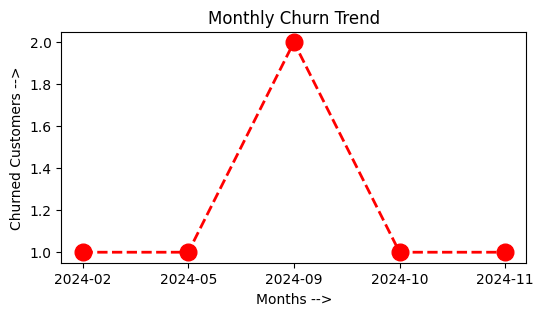

In [78]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(6,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='red', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Months -->')
plt.ylabel('Churned Customers -->')
plt.show()

In [79]:
# churn by plan type

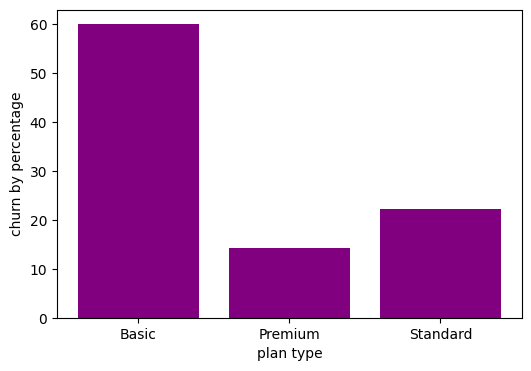

In [80]:
plt.figure(figsize=(6,4))

churn_plan = df_visual.groupby("plan_type")['churn_flag'].mean()*100

plt.bar(churn_plan.index , churn_plan.values ,color='purple')
plt.xlabel("plan type")
plt.ylabel("churn by percentage")
plt.show()

In [81]:
# churn by states

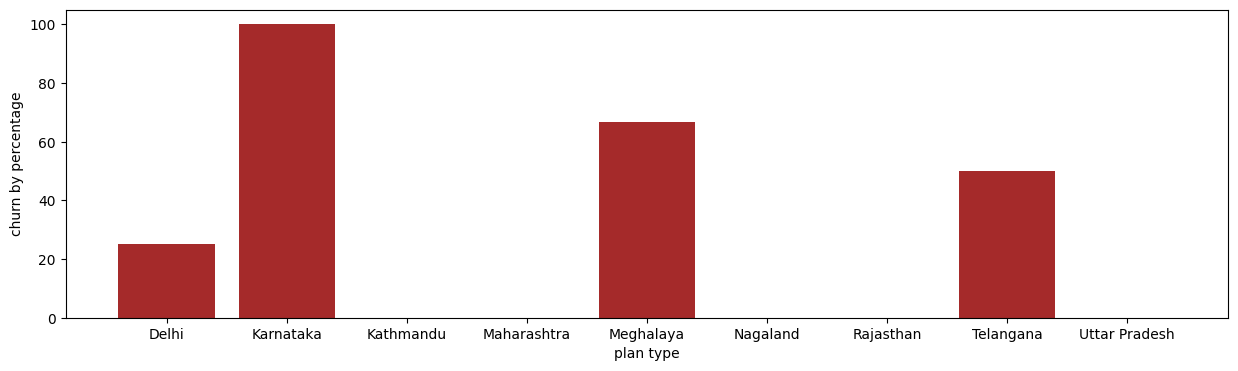

In [82]:
plt.figure(figsize=(15,4))

churn_state = df_visual.groupby("state")['churn_flag'].mean()*100
plt.bar(churn_state.index , churn_state.values ,color='brown')
plt.xlabel("plan type")
plt.ylabel("churn by percentage")
plt.show()

In [83]:
# churn by subscription

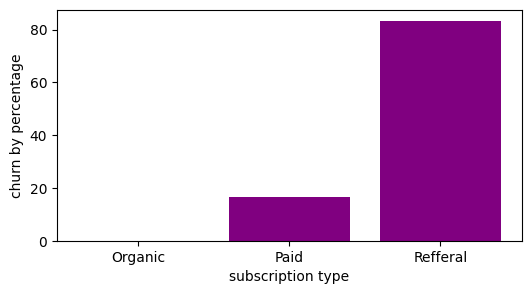

In [84]:
plt.figure(figsize=(6,3))

churn_subscription = df_visual.groupby("subscription_type")['churn_flag'].mean()*100
plt.bar(churn_subscription.index , churn_subscription.values ,color='purple')
plt.xlabel("subscription type")
plt.ylabel("churn by percentage")
plt.show()

In [85]:
# churn by escalations

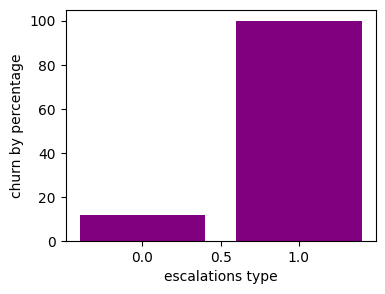

In [86]:
plt.figure(figsize=(4,3))

churn_escalations = df_visual.groupby("escalations")['churn_flag'].mean()*100
plt.bar(churn_escalations.index , churn_escalations.values ,color='purple')
plt.xlabel("escalations type")
plt.ylabel("churn by percentage")
plt.show()

In [87]:
# churn by gender

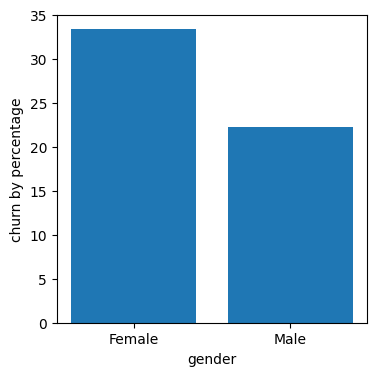

In [88]:
plt.figure(figsize=(4,4))

churn_gender = df_visual.groupby('gender')['churn_flag'].mean()*100

plt.bar(churn_gender.index , churn_gender.values)
plt.xlabel("gender")
plt.ylabel("churn by percentage")
plt.show()

In [89]:
# churn by contract_type

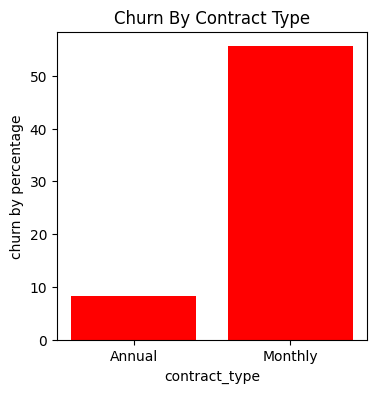

In [90]:
plt.figure(figsize=(4,4))

churn_contract_type= df_visual.groupby('contract_type')['churn_flag'].mean()*100

plt.bar(churn_contract_type.index , churn_contract_type.values, color='red')
plt.title("Churn By Contract Type")
plt.xlabel("contract_type")
plt.ylabel("churn by percentage")
plt.show()

In [91]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment', 'count',
       'tenure', 'age', 'churn_risk'],
      dtype='str')

In [92]:
df['contract_type'].unique()

<ArrowStringArray>
['Annual', 'Monthly']
Length: 2, dtype: str

In [93]:
# visualisation with seaborn sns

In [94]:
# encoding from str to int/numeric for heat map

In [95]:
df_encoded = df[['plan_type', 'contract_type', 
         'churn_score',
       'churn_flag', 'churn_risk' , 'escalations']]

categorical_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

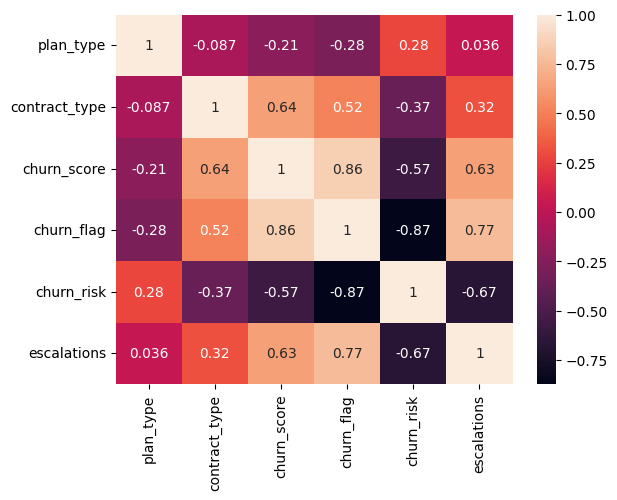

In [96]:
sns.heatmap(df_encoded.corr(),annot=True)

<Axes: >

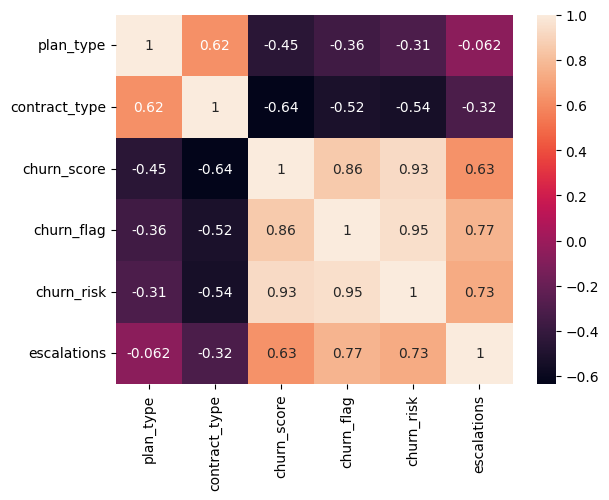

In [97]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

sns.heatmap(df_encoded.corr(),annot=True)

In [98]:
# pairplot

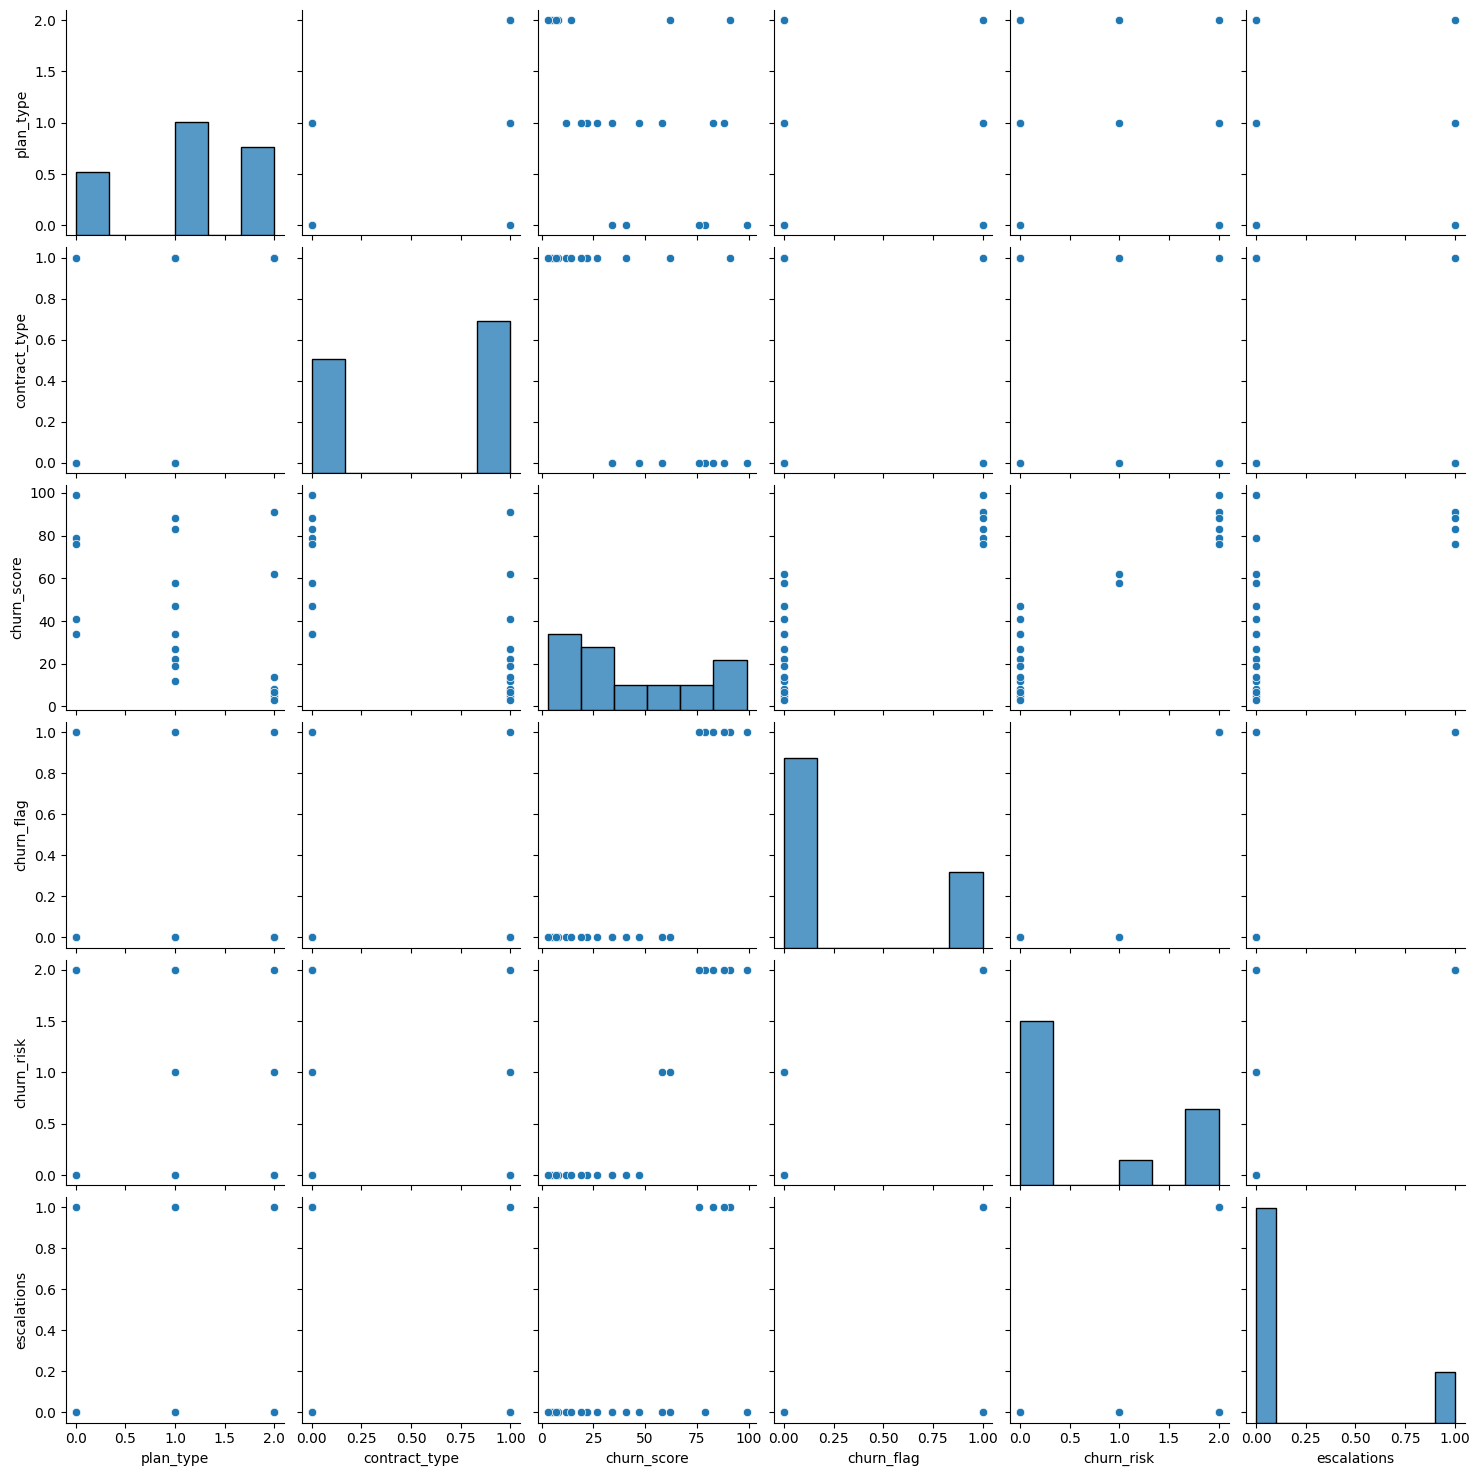

In [99]:
sns.pairplot(df_encoded)

In [100]:
# categorical plot in sns

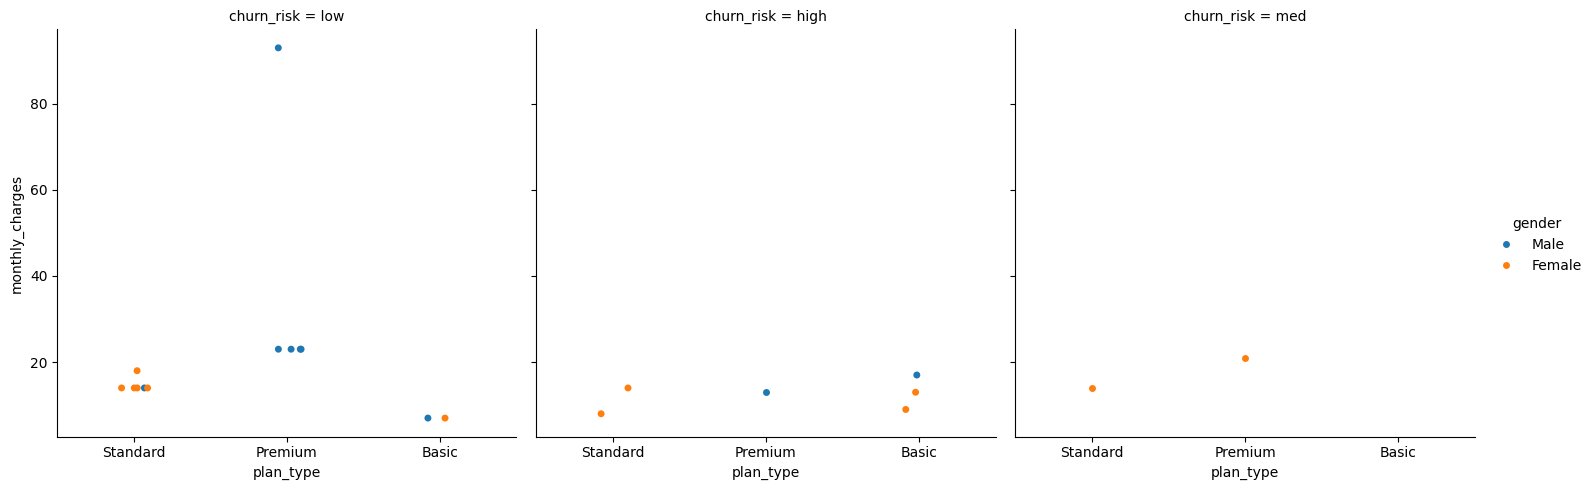

In [101]:
sns.catplot( data = df,
             x='plan_type',
             y='monthly_charges',
             hue='gender',
             col='churn_risk'
)

In [103]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment', 'count',
       'tenure', 'age', 'churn_risk'],
      dtype='str')

In [102]:
# pivot table

In [108]:
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['monthly_charges','churn_flag','tenure']
).reset_index()

,plan_type,churn_flag,monthly_charges,tenure
0,Basic,0.600000,10.590000,1038.200000
1,Premium,0.142857,31.275714,2058.142857
2,Standard,0.222222,13.767778,1301.111111
